In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

%load_ext autoreload
%autoreload 2

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
HDDL — Mini-projet 3 — ViT vs CNN
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Datasets : FOOD-101
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Présentation des réseaux</span>
            </a>
        </li>
        <ul style="list-style-type: circle; padding-left: 60px;">
            <li style="margin-bottom: 8px;">
            <a href="#11" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.1</span>
                <span style="color: #2c3e50; font-weight: 600;">CNN simple</span>
            </a>
        </li>
            <li style="margin-bottom: 8px;">
            <a href="#12" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.2</span>
                <span style="color: #2c3e50; font-weight: 600;">CNN complexe de type ResNet</span>
            </a>
        </li>
            <li style="margin-bottom: 8px;">
            <a href="#12" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.3</span>
                <span style="color: #2c3e50; font-weight: 600;">Vision Transformer</span>
            </a>
        </li>
        </ul>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Qu'est-ce qu'un CVAE et quelle est la différence avec un VAE classique ?</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Création d'un VAE</span>
            </a>
        </li>
        <ul style="list-style-type: circle; padding-left: 60px;">
            <li style="margin-bottom: 8px;">
            <a href="#31" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.1</span>
                <span style="color: #2c3e50; font-weight: 600;">Fonction de perte</span>
            </a>
        </li>
        </ul>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">Entraînement du VAE</span>
            </a>
        </li>
        <ul style="list-style-type: circle; padding-left: 60px;">
            <li style="margin-bottom: 8px;">
            <a href="#41" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.1</span>
                <span style="color: #2c3e50; font-weight: 600;">Entrainement pour différentes valeurs de beta</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#42" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.2</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualisation des espaces latents en fonction de beta</span>
            </a>
        </li>
         <li style="margin-bottom: 8px;">
            <a href="#43" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.3</span>
                <span style="color: #2c3e50; font-weight: 600;">Choix des hyperparamètres et entrainement du meilleur modèle</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#44" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.4</span>
                <span style="color: #2c3e50; font-weight: 600;">Reconstruction d'une donnée</span>
            </a>
        </li>
        </ul>
        <li style="margin-bottom: 8px;">
            <a href="#50" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">5.</span>
                <span style="color: #2c3e50; font-weight: 600;">Echantillonage avec le CVAE</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [2]:
import numpy as np

import pandas as pd
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import itertools
import json
from tqdm import tqdm

from data_extraction import compute_datasets_dataloaders, plot_dataset_distribution, compute_datasets_dataloaders_imagenet, plot_dataset_distribution_imagenet
from models.simpleCNN import CNN_classifier
from models.ResNetCNN import ComplexCNN
from models.ViT import ViT

import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from train import train_and_validate, plot_training, optim_param

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Présentation des réseaux
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Dans le cadre de ce projet, nous comparons les performances de trois réseaux différents :
<ul>
  <li>Un <strong> CNN "simple" </strong> constitué de 4 couches convolutionnelles similaires permettant d'augmenter les canaux et de diminuer la dimension spatiale, suivies d'un MLP pour la classification.</li>
  <li>Un <strong> CNN plus complexe de type ResNet </strong>, qui utilise des blocs résiduels constitués de 2 couches convolutionnelles pour apprendre une correction par rapport à l'entrée.</li>
  <li>Un <strong> Vision Transformer codé "à la main" </strong>, qui reprend la structure novatrice de Transformer avec des mécanismes d'attention. C'est la méthode la plus complexe.</li>
</ul>

<div id="11"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
1.1 CNN simple

```python

import torch
import torch.nn as nn

class CNN_classifier(nn.Module):
    def __init__(self, num_classes, im_size=224):
        super(CNN_classifier, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(2),
        )

        # On utilise AdaptiveAvgPool2d pour forcer la sortie à 1x1 pixel par canal, cela permet davantage de robustesse.
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes),
        )

        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.gap(x)
        x = self.fc_layers(x)
        return x


if __name__=='__main__':
    im_size=224
    x = torch.rand(1, 3, im_size, im_size)
    net = CNN_classifier(num_classes=10, im_size=im_size)
    
    out = net(x)

    print(f"Sortie : {out.shape}")    
    
# Il s'agit d'un code de CNN très simple avec seulement 4 couches convolutionnelles.


<div id="12"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
1.2 CNN complexe de type "ResNet"

```python

import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # Première convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False) 
                               # Le biais serait redondant avec celui utilisé dans le BatchNorm.
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        
        # Deuxième convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Le "Shortcut" (Le pont) : si on change la taille de l'image (stride > 1) ou le nombre de canaux, on doit adapter l'entrée pour pouvoir l'additionner à la sortie.
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.gelu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # L'addition magique : on ajoute l'entrée originale au résultat.
        out += self.shortcut(identity)
        out = self.gelu(out)
        
        return out

# Le bloc résiduel est la brique élémentaire de notre ResNet : son rôle est d'apprendre une correction (un résidu) par rapport à l'entrée plutôt que quelque chose de complètement nouveau.

class ComplexCNN(nn.Module):
    def __init__(self, num_classes, im_size=224):
        super(ComplexCNN, self).__init__()
        
        self.in_channels = 64
        
        # Entrée initiale : 224x224 -> 56x56 par le biais de la couche de départ ci-dessous. Elle permet d'avoir des blocs résiduels sur des objets plus petits.
        self.start_layer = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False), # Filtres 7x7 pour avoir un recul global sur l'image.
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # Couches résiduelles (de plus en plus de canaux, image de plus en plus petite)
        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)
        
        # Sortie globale
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        # Le premier bloc de la couche peut changer la résolution (stride).
        layers.append(ResidualBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        # Les blocs suivants gardent la même résolution.
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.start_layer(x) # [Batch, 64, 56, 56]
        
        x = self.layer1(x)      # [Batch, 64, 56, 56]
        x = self.layer2(x)      # [Batch, 128, 28, 28]
        x = self.layer3(x)      # [Batch, 256, 14, 14]
        x = self.layer4(x)      # [Batch, 512, 7, 7]
        
        x = self.gap(x)         # [Batch, 512, 1, 1]
        x = torch.flatten(x, 1) # [Batch, 512]
        x = self.classifier(x)  # [Batch, num_classes]
        
        return x

# Ce CNN est plus complexe : il est constitué d'un premier bloc de compression + 4 blocs résiduels (contenant chacun deux opérateurs convolutifs). Il reprend un mécanisme également présent dans le ViT, celui de correction de l'image de base (avec l'addition en sortie du bloc résiduel), il est donc une sorte d' "entre-deux".

<div id="13"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
1.3 Vision Transformer

```python

import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=16, embed_dim=768):
        super().__init__()
        # On utilise une convolution pour découper et projeter en une seule étape.
        self.projection = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        # x: [Batch, 3, 224, 224]
        x = self.projection(x) # [Batch, embed_dim, 14, 14]
        x = x.flatten(2)       # [Batch, embed_dim, 196]
        x = x.transpose(1, 2)  # [Batch, 196, embed_dim] (Format Séquence)
        return x
    
# Chaque patch est projeté dans un espace d'embedding à l'aide d'une Convolution 2D.

class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        # 1. La normalisation (on la définit ici pour l'utiliser avant l'attention)
        self.layernorm = nn.LayerNorm(embed_dim)
        
        # 2. Le mécanisme d'attention
        self.mha = nn.MultiheadAttention(
            embed_dim=embed_dim, 
            num_heads=num_heads, 
            dropout=dropout,      # Aide à éviter le sur-apprentissage (overfitting)
            batch_first=True
        )
        
        # 3. Le Dropout pour la régularisation après l'attention
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1. Copie pour la connexion résiduelle
        residual = x
        
        # 2. Pré-normalisation
        # On normalise d'abord (très important pour la stabilité)
        out = self.layernorm(x)
        
        # 3. Self-Attention
        # Query = Key = Value = out
        out, _ = self.mha(out, out, out)
        
        # --- Étape 4 : Dropout et Addition Résiduelle ---
        out = self.dropout(out)
        return out + residual

# On normalise l'embedding, on les divise en plusieurs morceaux (1 pour chaque tête) et on obtient par calcul matriciel les Q, K, V pour chaque tête. On applique ensuite un mécanisme d'attention pour chaque tête, on concatène les résultats, et on multiplie finalement par une matrice. On peut éventuellement faire un drop-out aléatoire sur la matrice obtenue, que ce soit après le softmax ou/et à la fin pour éviter de faire du sur-apprentissage sur des détails. 

class MLPBlock(nn.Module):
    def __init__(self, embed_dim, mlp_dim, dropout=0.1):
        super().__init__()
        self.layernorm = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(), # Activation standard des Transformers
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Norm + Add (succession standard pour les ViT)
        return self.mlp(self.layernorm(x)) + x
    
# Après chaque bloc d'attention, on fait une couche de feed-forward avec normalisation, on a un drop-out éventuel (extinction aléatoire des neurones et dans le résultat final). On utilise la fonction d'activation GeLU (Gaussian Error Linear Unit) qui est une version "lissée" et dérivable partout de ReLU, pour préserver le gradient pour les valeurs négatives.

class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=101, 
                 embed_dim=768, depth=12, num_heads=12, mlp_dim=3072, dropout_mha = 0.25, dropout_mlp = 0.25):
        super().__init__()
        
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim)
        num_patches = (img_size // patch_size) ** 2
        
        # 1. CLS Token et Positional Embedding (Paramètres apprenables)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim)*0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim)*0.02)
        
        # 2. Les blocs Transformer (Séquence de blocs)
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                MultiHeadAttentionBlock(embed_dim, num_heads, dropout_mha),
                MLPBlock(embed_dim, mlp_dim, dropout_mlp)                  
            ]))
        
        # 3. Tête de classification finale
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        b = x.shape[0]
        x = self.patch_embed(x)
        
        # Ajout du CLS token à chaque échantillon du batch
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # Ajout de l'encodage de position
        x = x + self.pos_embed
        
        for attn_block, mlp_block in self.layers:
            x = attn_block(x)
            x = mlp_block(x)
            
        # On ne garde que la sortie du CLS token pour prédire la classe
        return self.mlp_head(x[:, 0])
    
# Les paramètres d'entrée par défaut sont choisis conformément aux standards de référence proposés par Google dans le cadre de sa configuration "ViT-Base". Le CLS Token et le Position Embedding sont appris au même titre que les poids des réseaux. Ils ne sont pas initialisés à 0 pour que le modèle démarre rapidement. 
# Le CLS Token ne correspondant à rien de précis, à la suite de l'application du mécanisme d'attention, le premier vecteur va correspondre à une sorte de résumé global des informations fournies par tous les autres patches. C'est donc lui que l'on choisit en entrée du réseau pour la prédiction de classe.

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Comparaison des méthodes sur le jeu de données Food-101
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On choisit comme premier dataset le dataset Food-101 (disponible au téléchargement via https://huggingface.co/datasets/ethz/food101). Il contient 1000 images pour 101 plats différents, on cherche à comparer les différents réseaux sur la classification du plat à partir de l'image.

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Pré-traitement des données

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On récupère les données, on applique ensuite des techniques de Data Augmentation (random crop, flip horizontal, rotation), on normalise ensuite les valeurs pour obtenir les valeurs de moyenne et d'écart-type par bande habituellement utilisées par ImageNet. Enfin, on efface aléatoirement 25% des pixels (à nouveau de la Data Augmentation). Nous appliquons de nombreuses techniques de Data Augmentation pour éviter le sur-apprentissage (overfitting), en particulier pour le Vision Transformer qui nécessite beaucoup de données.

A partir des données, on peut créer des jeux d'entraînement (70% des données), de validation (10% des données) et de test (20% des données), contenues dans des batchs de taille 64 à l'aide d'un DataLoader. Le jeu de validation sera utilisé pour le choix des hyper-paramètres.

In [2]:
dataset_path="./food-101/images/"
batch_size=64

food_fulldataset,food_trainset,food_valset,food_testset,food_trainloader,food_valoader,food_testloader=compute_datasets_dataloaders(dataset_path,batch_size,train_size=0.7,val_size=0.1,data_augmentation=False,strong_data_augmentation=True)

class_names_food = food_fulldataset.classes
nb_classes_food=len(class_names_food)

Total: 101000
Train: 70700 images
Val:   10100 images
Test:  20200 images


/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/data_extraction.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_total, x='Classe', y='Nombre', ax=axes[0], palette='viridis')


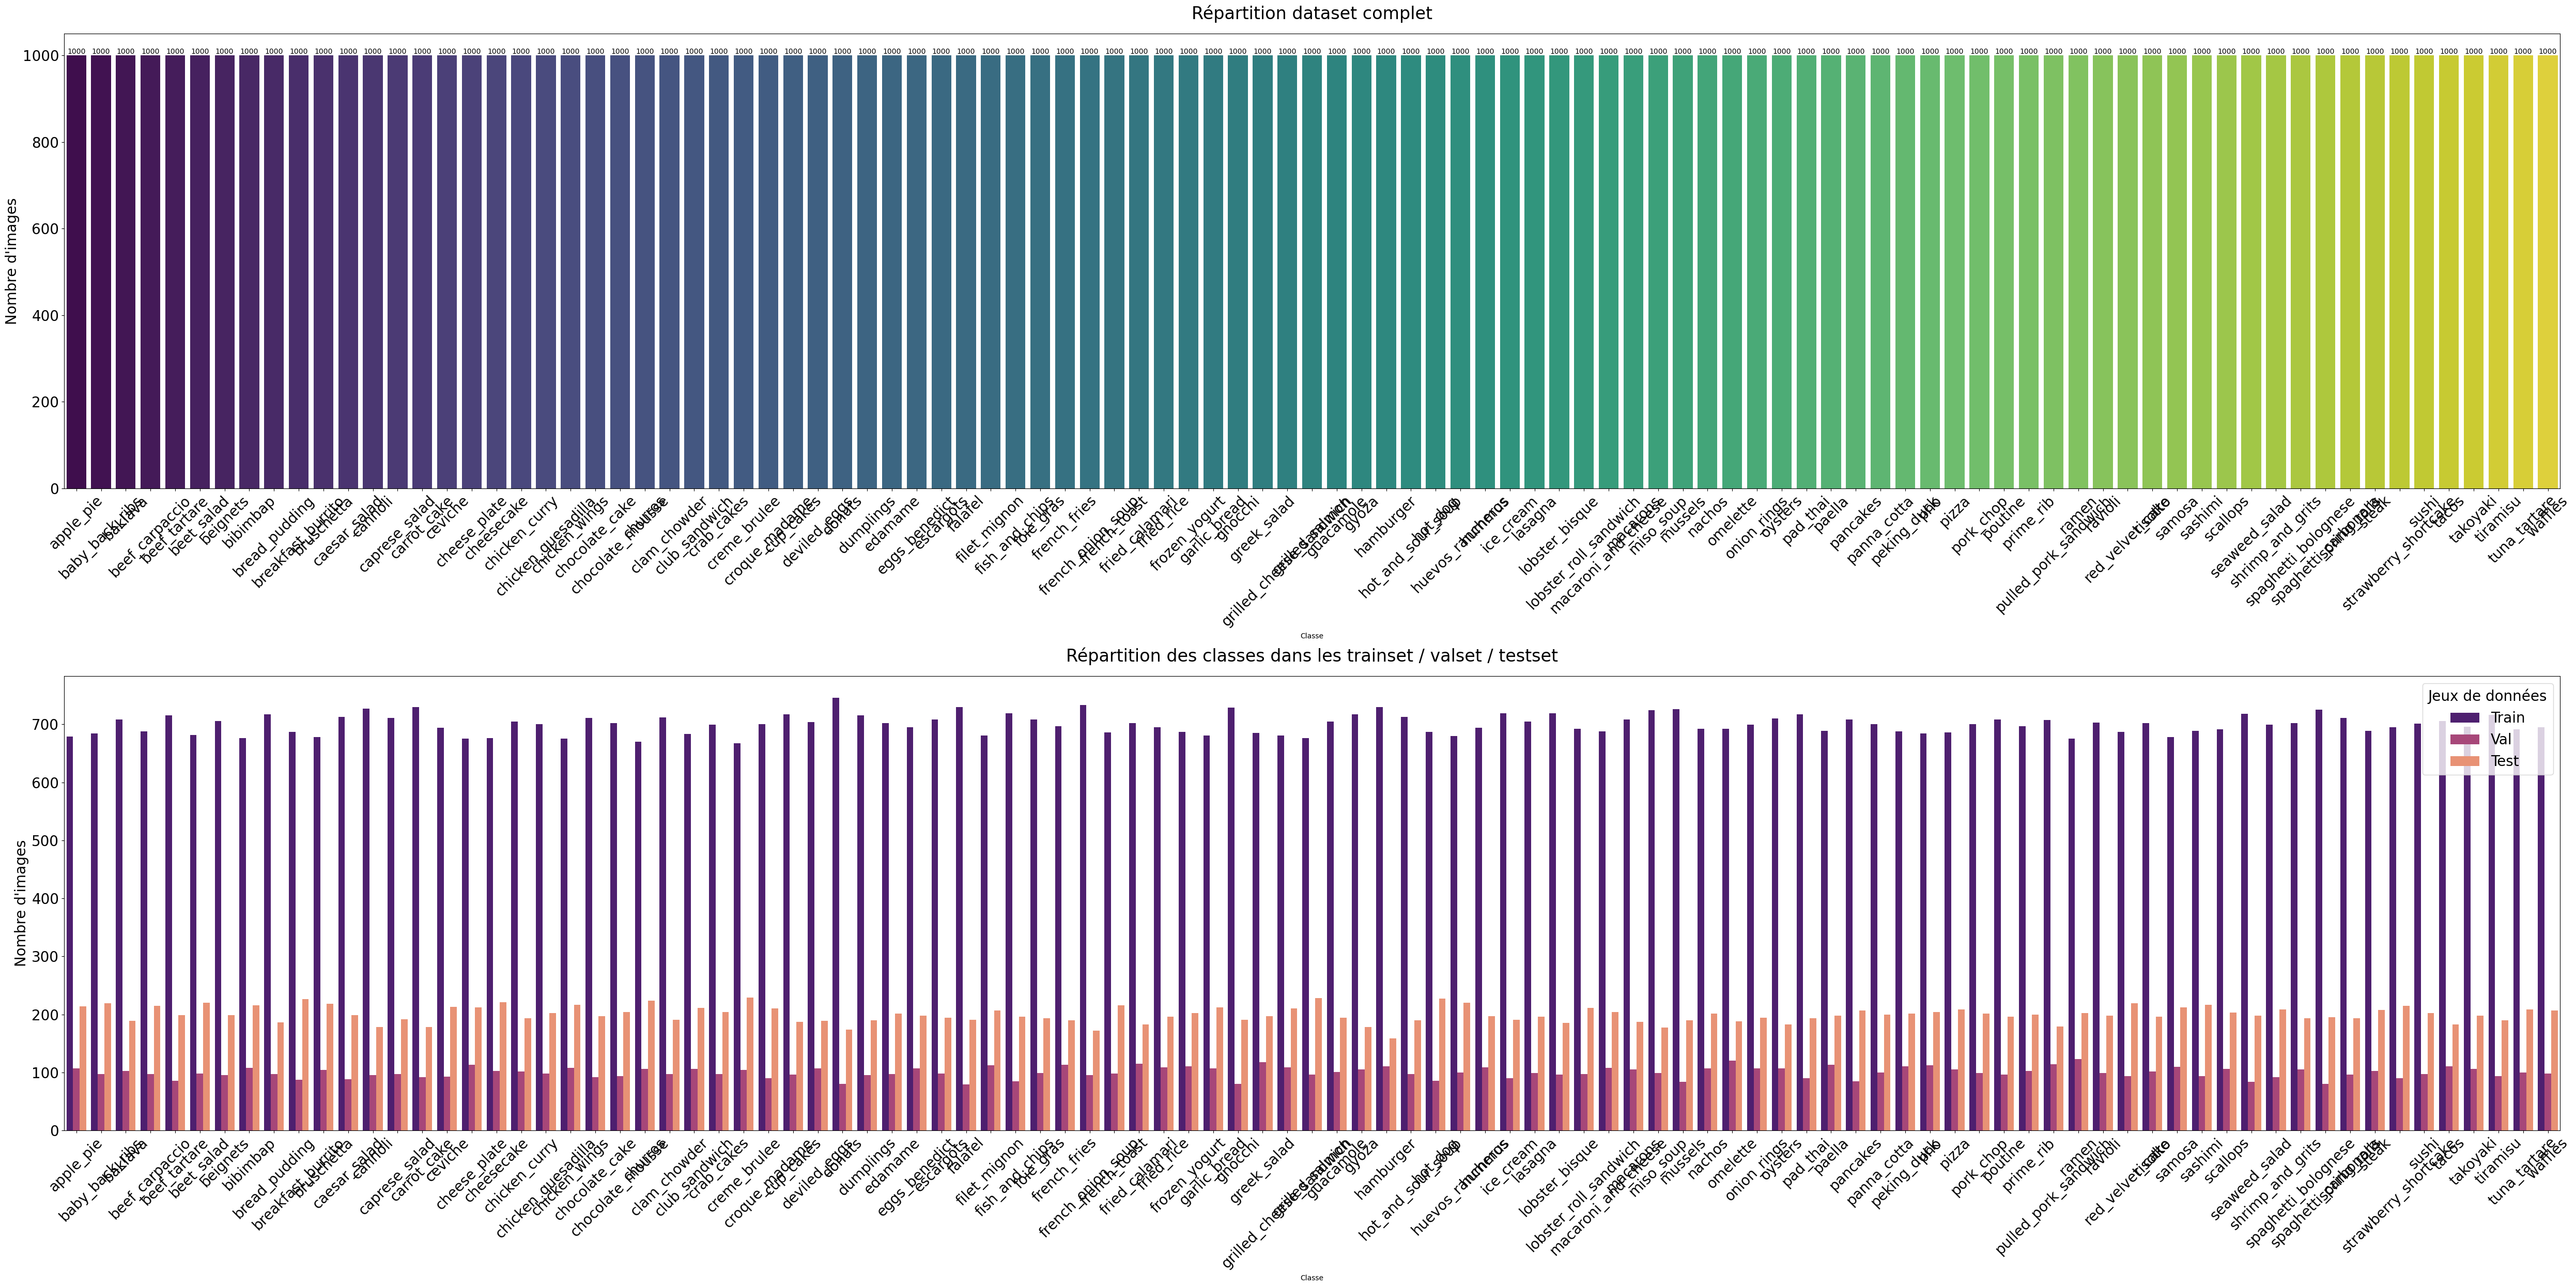

--- Récapitulatif ---
Set
Test     20200
Train    70700
Val      10100
Name: Nombre, dtype: int64


In [3]:
#Vérifiation de la répartition des classes

plot_dataset_distribution(food_fulldataset,food_trainset,food_valset,food_testset)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On remarque que malgré le découpage aléatoire en jeux d'entraînement, de validation et de test, les 101 classes semblent être réparties équitablement dans les trois jeux de données.

<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Entraînement des modèles

In [4]:
# Détection de la carte graphique
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

criterion = nn.CrossEntropyLoss()

cuda


In [ ]:
param_grid = {
        'lr': [1e-3, 1e-4],           # fixe le taux d'apprentissage maximal par paramètre
        'weight_decay': [1e-4, 1e-5], # paramètre de régularisation, évite d'avoir des poids inutiles
        'epochs': [5]                 # On teste sur peu d'époques pour gagner du temps
    }

model_class = CNN_classifier
saving_path='grid_search_results_cnn.json'
optimizer=optim.AdamW
best_param_CNNfood101=optim_param(model_class,nb_classes_food,param_grid,optimizer,food_trainloader,food_valoader, device,saving_path)

/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))


Lancement de la GridSearch : 4 combinaisons à tester.

--- Test 1/4 | Params: {'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 5} ---


Ép. 1/5 [Train]:   0%|          | 0/1105 [00:00<?, ?it/s]/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):
Ép. 1/5 [Train]: 100%|██████████| 1105/1105 [01:48<00:00, 10.22it/s, loss=4.3016]
/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:84: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


--> Fin Ép. 1 (122.7s) : Train Loss = 4.3033 Acc = 5.23% | Val Loss = 4.0381 Acc = 9.03%


Ép. 2/5 [Train]: 100%|██████████| 1105/1105 [01:49<00:00, 10.07it/s, loss=4.4717]


...

--> Fin Ép. 3 (123.8s) : Train Loss = 4.0545 Acc = 9.00% | Val Loss = 3.8775 Acc = 11.73%


Ép. 4/5 [Train]: 100%|██████████| 1105/1105 [01:49<00:00, 10.11it/s, loss=3.5861]


--> Fin Ép. 4 (123.8s) : Train Loss = 3.9621 Acc = 10.56% | Val Loss = 3.8018 Acc = 12.73%


Ép. 5/5 [Train]: 100%|██████████| 1105/1105 [01:45<00:00, 10.46it/s, loss=4.1262]


--> Fin Ép. 5 (119.4s) : Train Loss = 3.8848 Acc = 11.74% | Val Loss = 3.6577 Acc = 15.04%
Résultat : Accuracy Val = 15.04%


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

L'optimisation des hyper-paramètres suggère learning_rate=10<sup>-3</sup>, weight_decay=10<sup>-4</sup> pour le CNN simple.

On choisit également d'utiliser un Scheduler pour pouvoir diminuer (d'un facteur 10) le learning rate lorsqu'un plateau est atteint (au moins 5 epochs sans diminution de la perte de validation). Cela facilite la convergence et évite de faire de "trop grands pas". 

Pour le ViT, on utilise un Scheduler plus complexe. En effet, les couches d'attention sont très instables pour les ViT au début de l'apprentissage, il faut donc faire un échauffement (warmup) : on commence avec un taux d'apprentissage très bas et on l'augmente linéairement pendant plusieurs epochs, puis on le diminue (selon la forme d'un cosinus, on parle de "Cosine decay").

In [ ]:
model = CNN_classifier(num_classes=nb_classes_food).to(device)

optimizer = optim.AdamW(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4
)

checkpoint_path="weights/food101_SimpleCNN.pth"
save_info_path="infos_entrainement/food101_SimpleCNN.pth"
#Si le modèle a déjà été entraîné les poids, l'état de l'optimiseur et du scheduler sont rechargés automatiquement et on rajoute à
#l'entrainement le nombre d'époques spécifié ci dessous, cela permet de continuer à entrainer un modèle si le 'plateau' de loss
#n'a pas été atteint sans reprendre à 0.
nb_epochs = 1

#le scheduler réduit le lr si la loss de validation ne s'améliore pas pendant 5 époques
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# On appelle la fonction pour le CNN Simple
best_acc, training_info = train_and_validate(model, optimizer, food_trainloader, food_valoader, device,  checkpoint_path=checkpoint_path,save_info_path=save_info_path,epochs=nb_epochs,save_model=True,scheduler =scheduler)


/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))


Poids du modèle chargés avec succès.
État de l'optimiseur chargé avec succès.
État du scheduler chargé avec succès.
Reprise de l'entraînement à partir de l'époque 101. (Best Acc: 60.48%)


Ép. 102/102 [Train]:   0%|          | 0/1105 [00:00<?, ?it/s]/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):
Ép. 102/102 [Train]: 100%|██████████| 1105/1105 [01:38<00:00, 11.17it/s, loss=1.7694]
/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


--> Fin Ép. 102 (112.6s) : Train Loss = 1.9669 Acc = 50.90% | Val Loss = 1.5824 Acc = 59.49%
LR : 0.001000

[INFO] Résumé de l'entraînement sauvegardé dans : infos_entrainement/food101_SimpleCNN.pth
[INFO] Temps total : 1.9 min | Moyen/Ép : 161.1 sec


Temps total: 16325.5594830513 secondes


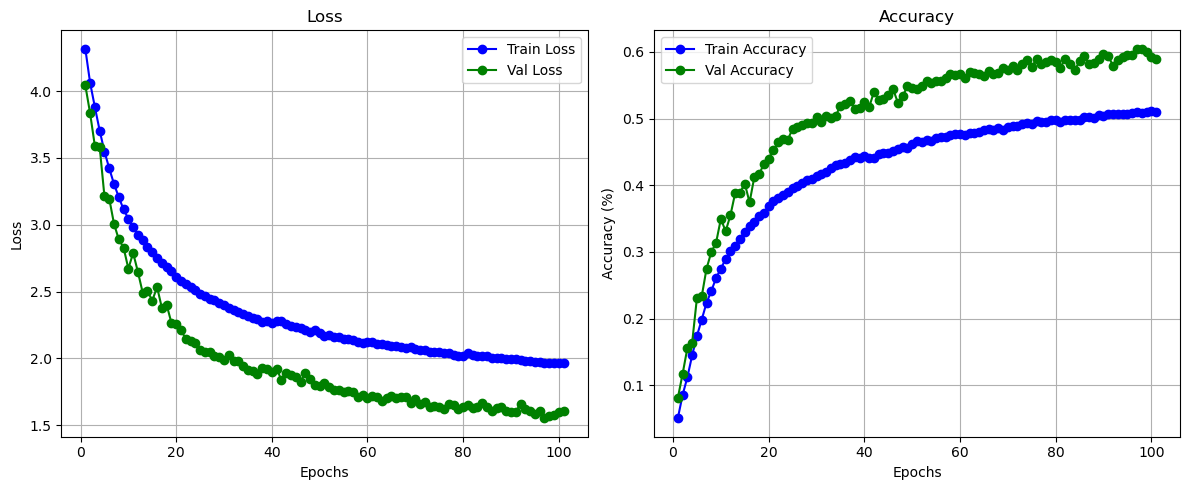

In [6]:
training_info_food101_SimpleCNN= torch.load("infos_entrainement/food101_SimpleCNN.pth")

print(f"Temps total: {training_info_food101_SimpleCNN['total_time_seconds']} secondes")

plot_training(training_info_food101_SimpleCNN)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

Le CNN simple converge vers .

In [7]:
param_grid = {
        'lr': [1e-3, 5e-3],           # fixe le taux d'apprentissage maximal par paramètre
        'weight_decay': [5e-3, 1e-3], # paramètre de régularisation, évite d'avoir des poids inutiles
        'epochs': [7]                 # On teste sur peu d'époques pour gagner du temps
    }

model_class = ComplexCNN
saving_path='grid_search_results_cnn.json'
optimizer=optim.AdamW
best_param_CNNfood101=optim_param(model_class,nb_classes_food,param_grid,optimizer,food_trainloader,food_valoader, device,saving_path)

Lancement de la GridSearch : 4 combinaisons à tester.

--- Test 1/4 | Params: {'lr': 0.001, 'weight_decay': 0.005, 'epochs': 7} ---


Ép. 1/7 [Train]: 100%|██████████| 1105/1105 [01:54<00:00,  9.69it/s, loss=4.0666]


--> Fin Ép. 1 (129.0s) : Train Loss = 4.3851 Acc = 4.55% | Val Loss = 4.1726 Acc = 6.54%


Ép. 2/7 [Train]: 100%|██████████| 1105/1105 [01:47<00:00, 10.28it/s, loss=3.9570]


--> Fin Ép. 2 (122.3s) : Train Loss = 4.0751 Acc = 8.61% | Val Loss = 3.7820 Acc = 13.09%


...

--> Fin Ép. 5 (123.8s) : Train Loss = 3.3446 Acc = 21.98% | Val Loss = 3.0241 Acc = 27.14%


Ép. 6/7 [Train]: 100%|██████████| 1105/1105 [01:47<00:00, 10.24it/s, loss=2.4779]


--> Fin Ép. 6 (122.1s) : Train Loss = 3.0722 Acc = 27.57% | Val Loss = 2.7049 Acc = 34.47%


Ép. 7/7 [Train]: 100%|██████████| 1105/1105 [01:49<00:00, 10.10it/s, loss=2.8048]


--> Fin Ép. 7 (124.4s) : Train Loss = 2.8217 Acc = 32.72% | Val Loss = 2.4336 Acc = 39.80%
Résultat : Accuracy Val = 39.80%


In [ ]:
"""

model = ComplexCNN(num_classes=nb_classes_food).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=1e-4, 
    weight_decay=1e-4
)

#le scheduler réduit le lr si la loss de validation ne s'améliore pas pendant 5 époques


checkpoint_path="weights/food101_ComplexCNN.pth"
save_info_path="infos_entrainement/food101_ComplexCNN.pth"
nb_epochs = 20

# On appelle la fonction pour le CNN Simple
best_acc, training_info = train_and_validate(model, optimizer, food_trainloader, food_valoader, device,  checkpoint_path=checkpoint_path,save_info_path=save_info_path,epochs=nb_epochs,save_model=True,scheduler=scheduler)

"""

Ép. 1/10 [Train]: 100%|██████████| 1105/1105 [01:34<00:00, 11.67it/s, loss=3.4373]


--> Fin Ép. 1 (107.7s) : Train Loss = 3.7077 Acc = 14.85% | Val Loss = 3.3352 Acc = 20.90%


Ép. 2/10 [Train]: 100%|██████████| 1105/1105 [01:34<00:00, 11.65it/s, loss=2.8722]


--> Fin Ép. 2 (108.2s) : Train Loss = 2.9045 Acc = 29.16% | Val Loss = 2.8184 Acc = 31.26%


Ép. 3/10 [Train]: 100%|██████████| 1105/1105 [01:34<00:00, 11.65it/s, loss=2.3508]


...

--> Fin Ép. 8 (107.8s) : Train Loss = 1.0132 Acc = 72.76% | Val Loss = 2.3571 Acc = 46.59%


Ép. 9/10 [Train]: 100%|██████████| 1105/1105 [01:34<00:00, 11.64it/s, loss=0.7567]


--> Fin Ép. 9 (107.7s) : Train Loss = 0.7523 Acc = 79.72% | Val Loss = 2.3375 Acc = 47.30%


Ép. 10/10 [Train]: 100%|██████████| 1105/1105 [01:34<00:00, 11.66it/s, loss=0.4499]


--> Fin Ép. 10 (107.6s) : Train Loss = 0.5164 Acc = 86.34% | Val Loss = 2.6282 Acc = 43.50%

[INFO] Résumé de l'entraînement sauvegardé dans : infos_entrainement/food101_ComplexCNN.pth
[INFO] Temps total : 18.0 min | Moyen/Ép : 107.7 sec


In [6]:
model = ComplexCNN(num_classes=nb_classes_food).to(device)

optimizer = optim.AdamW(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-3
)

#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

checkpoint_path="weights/food101_ComplexCNN.pth"
save_info_path="infos_entrainement/food101_ComplexCNN.pth"
nb_epochs = 1

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# On appelle la fonction pour le CNN Simple
best_acc, training_info = train_and_validate(model, optimizer, food_trainloader, food_valoader, device,  checkpoint_path=checkpoint_path,save_info_path=save_info_path,epochs=nb_epochs,save_model=True,scheduler=scheduler)

Poids du modèle chargés avec succès.
État de l'optimiseur chargé avec succès.
État du scheduler chargé avec succès.
Reprise de l'entraînement à partir de l'époque 41. (Best Acc: 67.58%)


Ép. 42/42 [Train]: 100%|██████████| 1105/1105 [01:39<00:00, 11.10it/s, loss=0.7449]


--> Fin Ép. 42 (113.0s) : Train Loss = 0.9470 Acc = 75.23% | Val Loss = 1.2084 Acc = 70.47%
Meilleure val accuracy, modèle sauvegardé !
LR : 0.000100

[INFO] Résumé de l'entraînement sauvegardé dans : infos_entrainement/food101_ComplexCNN.pth
[INFO] Temps total : 1.9 min | Moyen/Ép : 151.3 sec


Temps total: 6280.882274150848 secondes


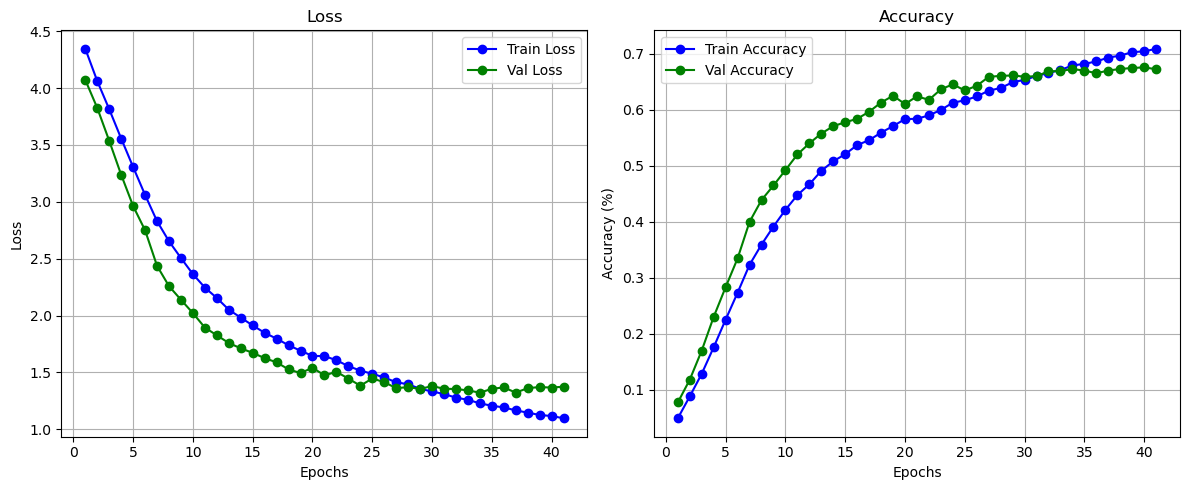

In [8]:
training_info_food101_ComplexCNN= torch.load("infos_entrainement/food101_ComplexCNN.pth")

print(f"Temps total: {training_info_food101_ComplexCNN['total_time_seconds']} secondes")

plot_training(training_info_food101_ComplexCNN)

weight_decay=5e-2 : Les ViT ont besoin d'une régularisation forte pour ne pas overfitter. 0.05 est la valeur standard utilisée dans le papier DeiT (Data-efficient Image Transformers).

Warmup (LinearLR) : Les couches d'attention (Self-Attention) sont très instables au tout début. Si on commence direct à 1e-3, les gradients risquent d'exploser.

Cosine Annealing : Permet de baisser le lr progressivement our mieux converger

In [ ]:
#--------------------------RUN PAS CETTE CELLULE -------------------------------------------

model = ViT(num_classes=nb_classes_food).to(device)

optimizer = optim.AdamW(
    model.parameters(), 
    lr=1e-3,
    weight_decay=5e-2
)

nb_epochs_total = 100
nb_epochs = 0
warmup_epochs = 10  # 5 à 10 époques de chauffe

#définition des schedulers

# scheduler qui augmente le lr linéairement pendant quelques époques pour stabiliser les gradients 
scheduler_warmup = LinearLR(
    optimizer, 
    start_factor=0.01, 
    end_factor=1.0, 
    total_iters=warmup_epochs
)

# Scheduler 2 : Cosine Decay (descend de lr à 0 sur le reste du temps) :  au début apprends vite puis affine
scheduler_decay = CosineAnnealingLR(
    optimizer, 
    T_max=nb_epochs_total - warmup_epochs,
    eta_min=1e-6  # On ne descend pas tout à fait à 0
)

# Le Scheduler Principal qui enchaîne les deux
scheduler = SequentialLR(
    optimizer, 
    schedulers=[scheduler_warmup, scheduler_decay], 
    milestones=[warmup_epochs]
)

checkpoint_path="weights/food101_ViT.pth"
save_info_path="infos_entrainement/food101_ViT.pth"


best_acc, training_info = train_and_validate(model, optimizer, food_trainloader, food_valoader, device,  checkpoint_path=checkpoint_path,save_info_path=save_info_path,epochs=nb_epochs,save_model=True, scheduler=scheduler)

/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == 'cuda'))


Début de l'entraînement à partir de zéro.


Ép. 1/20 [Train]:   0%|          | 0/1105 [00:00<?, ?it/s]/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):
Ép. 1/20 [Train]: 100%|██████████| 1105/1105 [11:16<00:00,  1.63it/s, loss=4.3813]
/home/ehrhart/Bureau/HDDL/vit/HDDL/vit_cnn/train.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


--> Fin Ép. 1 (704.7s) : Train Loss = 4.5098 Acc = 3.21% | Val Loss = 4.3412 Acc = 4.76%
Meilleure vac accuracy, modèle sauvegardé !
LR : 0.000109


Ép. 2/20 [Train]: 100%|██████████| 1105/1105 [11:26<00:00,  1.61it/s, loss=4.1726]


...

--> Fin Ép. 18 (719.6s) : Train Loss = 3.8825 Acc = 11.85% | Val Loss = 3.7148 Acc = 14.57%
Meilleure vac accuracy, modèle sauvegardé !
LR : 0.000981


Ép. 19/20 [Train]: 100%|██████████| 1105/1105 [11:27<00:00,  1.61it/s, loss=3.5731]


--> Fin Ép. 19 (716.3s) : Train Loss = 3.8298 Acc = 12.92% | Val Loss = 3.6483 Acc = 15.52%
Meilleure vac accuracy, modèle sauvegardé !
LR : 0.000976


Ép. 20/20 [Train]: 100%|██████████| 1105/1105 [11:32<00:00,  1.59it/s, loss=3.7206]


--> Fin Ép. 20 (722.0s) : Train Loss = 3.7932 Acc = 13.55% | Val Loss = 3.6790 Acc = 15.40%
LR : 0.000970

[INFO] Résumé de l'entraînement sauvegardé dans : infos_entrainement/food101_ViT.pth
[INFO] Temps total : 242.7 min | Moyen/Ép : 724.1 sec


Temps total: 14562.880030155182 secondes


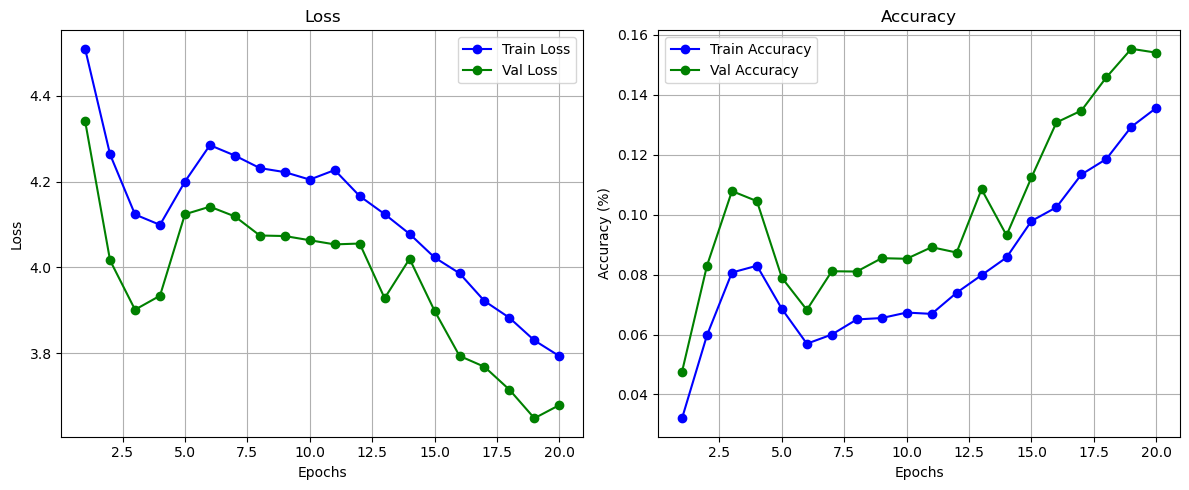

In [6]:
training_info_food101_ViT= torch.load("infos_entrainement/food101_ViT_1st_training.pth")

print(f"Temps total: {training_info_food101_ViT['total_time_seconds']} secondes")

plot_training(training_info_food101_ViT)

In [8]:
#--------------------------RUN CETTE CELLULE -------------------------------------------

model = ViT(num_classes=nb_classes_food).to(device)

optimizer = optim.AdamW(
    model.parameters(), 
    lr=4e-4,
    weight_decay=5e-2
)

nb_epochs_total = 100
nb_epochs = 20
warmup_epochs = 5  # 5 à 10 époques de chauffe

#définition des schedulers

# scheduler qui augmente le lr linéairement pendant quelques époques pour stabiliser les gradients 
scheduler_warmup = LinearLR(
    optimizer, 
    start_factor=0.01, 
    end_factor=1.0, 
    total_iters=warmup_epochs
)

# Scheduler 2 : Cosine Decay (descend de lr à 0 sur le reste du temps) :  au début apprends vite puis affine
scheduler_decay = CosineAnnealingLR(
    optimizer, 
    T_max=nb_epochs_total - warmup_epochs,
    eta_min=1e-6  # On ne descend pas tout à fait à 0
)

# Le Scheduler Principal qui enchaîne les deux
scheduler = SequentialLR(
    optimizer, 
    schedulers=[scheduler_warmup, scheduler_decay], 
    milestones=[warmup_epochs]
)

checkpoint_path="weights/food101_ViT.pth"
save_info_path="infos_entrainement/food101_ViT.pth"


best_acc, training_info = train_and_validate(model, optimizer, food_trainloader, food_valoader, device,  checkpoint_path=checkpoint_path,save_info_path=save_info_path,epochs=nb_epochs,save_model=True, scheduler=scheduler)

Poids du modèle chargés avec succès.
État de l'optimiseur chargé avec succès.
État du scheduler chargé avec succès.
Reprise de l'entraînement à partir de l'époque 40. (Best Acc: 44.86%)


Ép. 41/60 [Train]:  18%|█▊        | 204/1105 [02:11<09:41,  1.55it/s, loss=2.4404]


KeyboardInterrupt: 

Temps total: 28760.955047369003 secondes


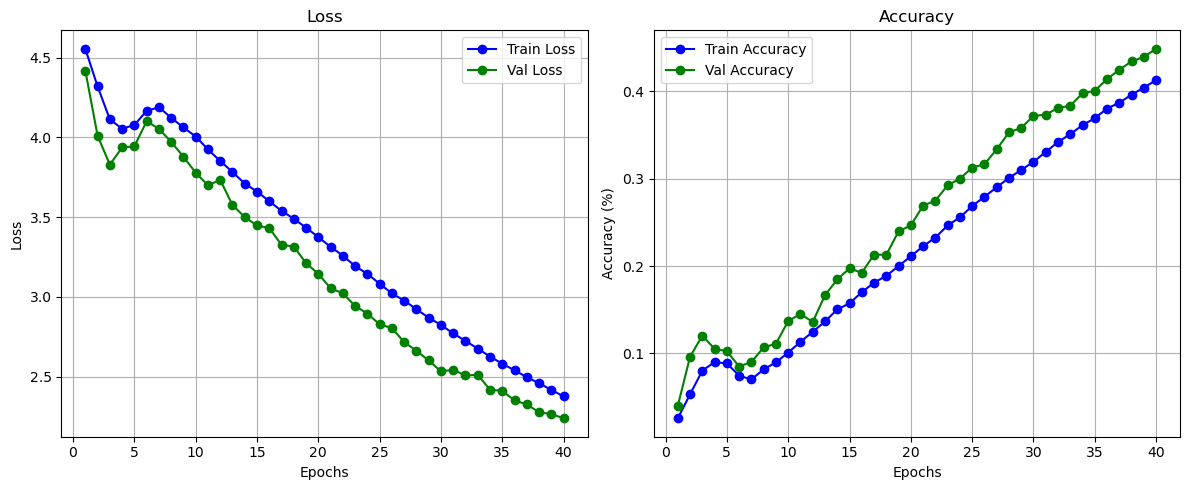

In [7]:
training_info_food101_ViT= torch.load("infos_entrainement/food101_ViT.pth")

print(f"Temps total: {training_info_food101_ViT['total_time_seconds']} secondes")

plot_training(training_info_food101_ViT)

# Chargement des modèles entrainés

In [ ]:
#chargement des modèles
path = 'weights/ffood101_SimpleCNN.pth'
model_simpleCNN = CNN_classifier(num_classes=nb_classes_food, im_size=224).to(device)
checkpoint=torch.load(path)

model_simpleCNN.load_state_dict(checkpoint['model_state_dict'])
print("Poids du modèle chargés avec succès")

In [ ]:
path = 'weights/food101_ComplexCNN.pth'
model_complexCNN = ComplexCNN(num_classes=nb_classes_food, im_size=224).to(device)
checkpoint=torch.load(path)

model_complexCNN.load_state_dict(checkpoint['model_state_dict'])
print("Poids du modèle chargés avec succès")

In [ ]:
path = 'weights/food101_ViT.pth'
model_ViT = ViT(num_classes=nb_classes_food, im_size=224).to(device)
checkpoint=torch.load(path)

model_ViT.load_state_dict(checkpoint['model_state_dict'])
print("Poids du modèle chargés avec succès")


<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Comparaison des méthodes sur le jeu de données Tiny ImageNet
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On utilise également pour la comparaison de nos trois modèles "maison" le jeu de données Tiny ImageNet ( disponible depuis http://cs231n.stanford.edu/tiny-imagenet-200.zip).

Ce jeu de données contient des images de dimension spatiale 64x64 pixels, on va donc devoir appliquer un "upscaling" pour pouvoir appliquer nos méthodes (qui sont pensées pour des images de dimension 224x224 pixels). On pourra donc tester les méthodes sur des images de plus basse définition.

Les classes sont également plus diverses (animaux, objets, fruits...) : les modèles doivent apprendre des concepts visuels très différents. Il y a également moins d'images par classe pour l'entraînement que pour Food-101 (500 contre 1000 pour Food-101).

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Pré-traitement des données

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On a appliqué un script de réorganisation (disponible dans le dossier tiny-imagenet-200) pour réorganiser le dossier val des images. Les images du dossier val étant annotées et celles du dossier test non (le jeu de données est extrait d'un défi Kaggle), nous allons utiliser les images du dossier val comme jeu de test.

In [3]:
dataset_path="./tiny-imagenet-200/tiny-imagenet-200/"
batch_size=64

imagenet_trainset,imagenet_valset,imagenet_trainloader,imagenet_valoader=compute_datasets_dataloaders_imagenet(dataset_path,batch_size, data_augmentation=False,strong_data_augmentation=True)

class_names_imagenet = imagenet_trainset.classes
nb_classes_imagenet=len(class_names_imagenet)

Mode: Strong Data Augmentation (RandAugment + Erasing)
------------------------------
Chargement depuis : ./tiny-imagenet-200/tiny-imagenet-200/
Train images : 100000 (Classes: 200)
Val images   : 10000   (Classes: 200)
------------------------------


c:\Users\arman\Desktop\HDDL\Projet 3\HDDL\vit_cnn\data_extraction.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_total, x='Classe', y='Nombre', ax=axes[0], palette='viridis')


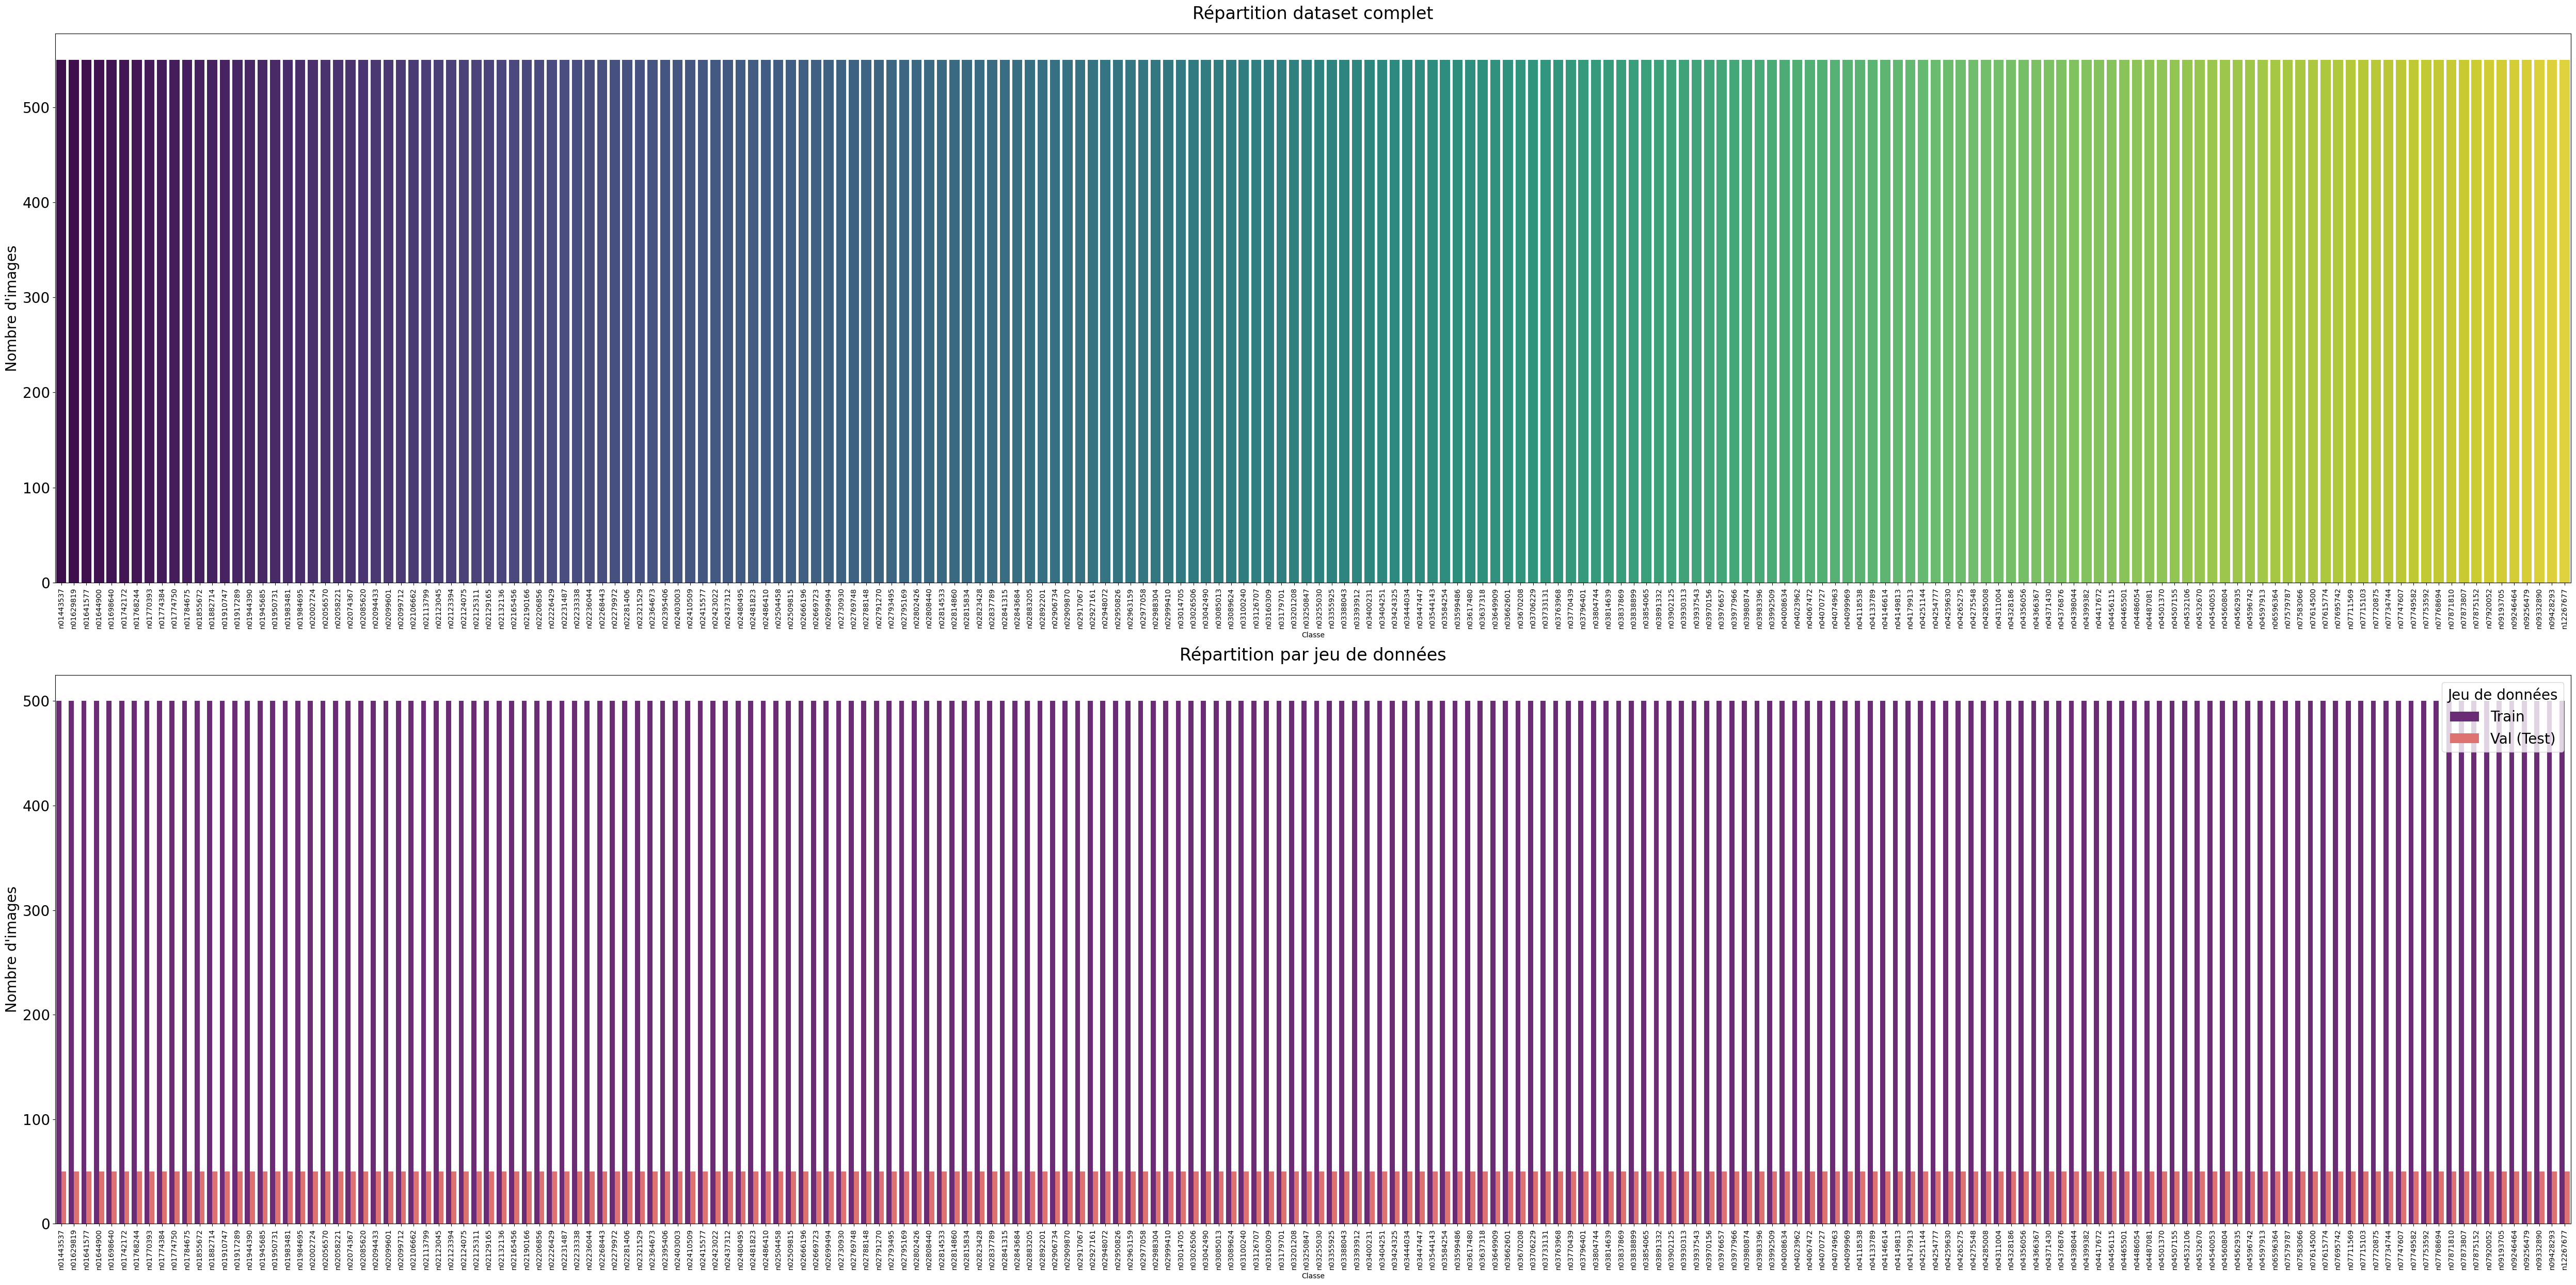

--- Récapitulatif ---
Set
Train         100000
Val (Test)     10000
Name: Nombre, dtype: int64


In [4]:
#Vérifiation de la répartition des classes

plot_dataset_distribution_imagenet(imagenet_trainset,imagenet_valset)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On remarque que les 200 classes sont réparties équitablement dans le jeu d'entraînement et le jeu de test.

<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Entraînement des modèles

In [5]:
# Détection de la carte graphique
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

criterion = nn.CrossEntropyLoss()

cuda


In [8]:
model = CNN_classifier(num_classes=nb_classes_imagenet).to(device)

optimizer = optim.AdamW(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4
)

checkpoint_path="weights/imagenet_SimpleCNN.pth"
save_info_path="infos_entrainement/imagenet_SimpleCNN.pth"
#Si le modèle a déjà été entraîné les poids, l'état de l'optimiseur et du scheduler sont rechargés automatiquement et on rajoute à
#l'entrainement le nombre d'époques spécifié ci dessous, cela permet de continuer à entrainer un modèle si le 'plateau' de loss
#n'a pas été atteint sans reprendre à 0.
nb_epochs = 50

#le scheduler réduit le lr si la loss de validation ne s'améliore pas pendant 5 époques
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# On appelle la fonction pour le CNN Simple
best_acc, training_info = train_and_validate(model, optimizer, imagenet_trainloader, imagenet_valoader, device,  checkpoint_path=checkpoint_path,save_info_path=save_info_path,epochs=nb_epochs,save_model=True,scheduler =scheduler)


Poids du modèle chargés avec succès.
État de l'optimiseur chargé avec succès.
État du scheduler chargé avec succès.
Reprise de l'entraînement à partir de l'époque 1. (Best Acc: 6.76%)


Ép. 2/51 [Train]: 100%|██████████| 1563/1563 [02:39<00:00,  9.82it/s, loss=4.5112]


--> Fin Ép. 2 (196.9s) : Train Loss = 4.6060 Acc = 6.58% | Val Loss = 4.1703 Acc = 11.33%
Meilleure val accuracy, modèle sauvegardé !
LR : 0.001000


Ép. 3/51 [Train]: 100%|██████████| 1563/1563 [02:51<00:00,  9.13it/s, loss=4.5458]


--> Fin Ép. 3 (211.0s) : Train Loss = 4.4000 Acc = 8.94% | Val Loss = 3.9805 Acc = 13.76%
Meilleure val accuracy, modèle sauvegardé !
LR : 0.001000


...

--> Fin Ép. 49 (146.1s) : Train Loss = 3.2383 Acc = 27.43% | Val Loss = 2.5900 Acc = 38.76%
Meilleure val accuracy, modèle sauvegardé !
LR : 0.001000


Ép. 50/51 [Train]: 100%|██████████| 1563/1563 [02:08<00:00, 12.17it/s, loss=2.9230]


--> Fin Ép. 50 (146.2s) : Train Loss = 3.2337 Acc = 27.39% | Val Loss = 2.5891 Acc = 39.04%
Meilleure val accuracy, modèle sauvegardé !
LR : 0.001000


Ép. 51/51 [Train]:  52%|█████▏    | 819/1563 [01:11<01:05, 11.40it/s, loss=3.1656]


KeyboardInterrupt: 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">

On réutilise les paramètres de learning_rate et de weight_decay obtenus avec notre quadrillage sur Food-101 pour gagner du temps.

# Reste à faire  

Basculer les modèles et l'explication du vit dans le rapport, expliquer l'architecture des CNN (Arman) 

Autres datasets : (Arman et Elsa)
MNIST OU TEXTURE si bon dataset textures   
tACHE SUR LES FOULES ou plus complexe avec des modèles pré-entrainés  

comparer les entrrainements des modèles,  eventuellement superposer les courbes, ne pas oublier de mentionner le temps d'entrainement, nombre d'epoques, computationnal budget (paramètres, calculs) (Guillaume)  
comparer les résultats : confusion matrice, acc, precision, recall, f1 scores sur le test, inference time (Guillaume)  
Partie interprétabilité avec la partie de Bertoin (Paul)  
Comparer avec litterature (Guillaume) mais on aide aussi



# Un peu de litterature

DOSOVITSKIY et al. : les ViT entrainés avec beaucoup d'images sont très performants, dans le ca de l'articles ils parent de 14 à 300 millions d'images. Les meilleuts modèle 

# References

DOSOVITSKIY, Alexey. An image is worth 16x16 words: Transformers for image recognition at scale. arXiv preprint arXiv:2010.11929, 2020.